In [1]:
import os
import glob
import pandas as pd

DATA_ROOT = os.path.join("data", "ami")

AUDIO_DIR = os.path.join(DATA_ROOT, "audio")
SUMMARY_DIR = os.path.join(DATA_ROOT, "summary")
TRANSCRIPT_DIR = os.path.join(DATA_ROOT, "transcript")

In [2]:
def parse_transcript(filepath):

    utterances = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            parts = line.strip().split("\t")

            if len(parts) != 4:
                print('Transcript line parts mismatch')
                continue

            speaker, start_time, text, section = parts

            utterances.append({
                "speaker": speaker,
                "start_time": float(start_time),
                "text": text,
                "section": section
            })

    utterance_df = pd.DataFrame(utterances)

    if len(utterance_df) == 0:
        return "", utterance_df

    # Build full transcript text
    transcript_text = " ".join(utterance_df["text"].tolist())

    return transcript_text, utterance_df

In [3]:
def load_transcripts(transcript_dir):

    records = []

    for split in ["train", "valid", "test"]:

        split_dir = os.path.join(transcript_dir, split)

        for filepath in glob.glob(os.path.join(split_dir, "*.txt")):

            meeting_id = os.path.basename(filepath).replace(".txt", "")

            transcript_text, utterance_df = parse_transcript(filepath)

            records.append({
                "meeting_id": meeting_id,
                "split": split,
                "transcript": transcript_text,
                "num_utterances": len(utterance_df),
                "num_speakers": utterance_df["speaker"].nunique()
            })

    return pd.DataFrame(records)

In [4]:
def load_summaries(summary_dir):

    summaries = {}

    for filepath in glob.glob(os.path.join(summary_dir, "*.txt")):
        meeting_id = os.path.basename(filepath).replace(".txt", "")

        with open(filepath, "r", encoding="utf-8") as f:
            summaries[meeting_id] = f.read()

    return summaries

In [5]:
def load_audio_paths(audio_dir):

    audio_records = []

    for meeting in os.listdir(audio_dir):

        meeting_audio_dir = os.path.join(audio_dir, meeting, "audio")

        if not os.path.isdir(meeting_audio_dir):
            continue

        headset = None
        lapel = None

        for file in os.listdir(meeting_audio_dir):

            if "Headset" in file:
                headset = os.path.join(meeting_audio_dir, file)

            if "Lapel" in file:
                lapel = os.path.join(meeting_audio_dir, file)

        audio_records.append({
            "meeting_id": meeting,
            "audio_headset": headset,
            "audio_lapel": lapel
        })

    return pd.DataFrame(audio_records)

In [ ]:
def build_dataset():
    transcripts_df = load_transcripts(TRANSCRIPT_DIR)

    summaries = load_summaries(SUMMARY_DIR)

    audio_df = load_audio_paths(AUDIO_DIR)

    # attach summaries
    transcripts_df["summary"] = transcripts_df["meeting_id"].map(summaries)

    # merge audio paths
    df = transcripts_df.merge(audio_df, on="meeting_id", how="left")
    
    # get the transcript and summary lengths in tokens, and the ratio of summary length to transcript length
    # we also tested character counts, but the ratios were very similar to token counts
    df['transcript_length'] = df['transcript'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['summary_length'] = df['summary'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df['ratio_summary_to_transcript'] = df.apply(lambda row: row['summary_length'] / row['transcript_length'] if row['transcript_length'] > 0 else 0, axis=1)

    return df

In [13]:
df = build_dataset()

print(df.shape)
print(df.head())

(137, 11)
  meeting_id  split                                         transcript  \
0    ES2002a  train  Okay . Right . Um well this is the kick-off me...   
1    ES2002b  train  Is that alright now ? Okay . Sorry ? Okay , ev...   
2    ES2002c  train  'S to do now is to decide how to fulfil what y...   
3    ES2002d  train  Okay we all all set ? Right . Well this is the...   
4    ES2005a  train  Uh , making a profit of fifty million Euros . ...   

   num_utterances  num_speakers  \
0             332             4   
1             691             4   
2             634             4   
3             854             4   
4              93             4   

                                             summary  \
0  The project manager introduced the upcoming pr...   
1  The project manager briefed the team on some n...   
2  The project manager recapped the decisions mad...   
3  The project manager recapped the decisions mad...   
4  The group discussed their initial ideas about ...  

In [ ]:
# print train/valid/test split counts
print("Split counts:")
print(df["split"].value_counts())

# print a count of missing values (which would need some fill in / default)
print("\nMissing summaries:")
print(df["summary"].isna().sum())

print("\nMissing audio:")
print(df["audio_headset"].isna().sum())

Split counts:
split
train    97
valid    20
test     20
Name: count, dtype: int64

Missing summaries:
0

Missing audio:
0


In [ ]:

import matplotlib.pyplot as plt

# print descriptive statistics for lengths and ratios to see the range and distribution
print(df[['transcript_length', 'summary_length', 'ratio_summary_to_transcript']].describe())


       transcript_length  summary_length  ratio_summary_to_transcript
count         137.000000      137.000000                   137.000000
mean         5720.218978      286.905109                     0.056120
std          2286.425346       94.047069                     0.022325
min           891.000000       84.000000                     0.023728
25%          3804.000000      235.000000                     0.040966
50%          5767.000000      288.000000                     0.051540
75%          7393.000000      339.000000                     0.067456
max         11218.000000      652.000000                     0.159195


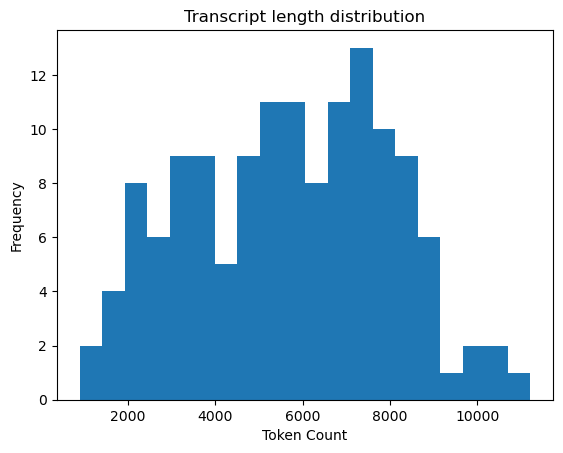

In [ ]:
# plot histograms of length and ratio distributions to see the range and distribution more visually

plt.hist(df["transcript_length"], bins=20)
plt.title("Transcript length distribution")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

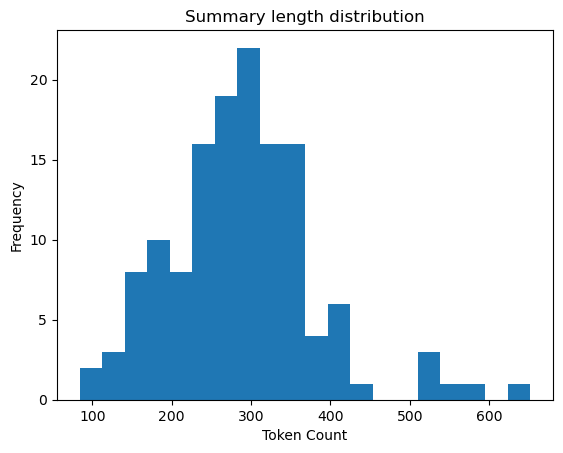

In [36]:
plt.hist(df["summary_length"], bins=20)
plt.title("Summary length distribution")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

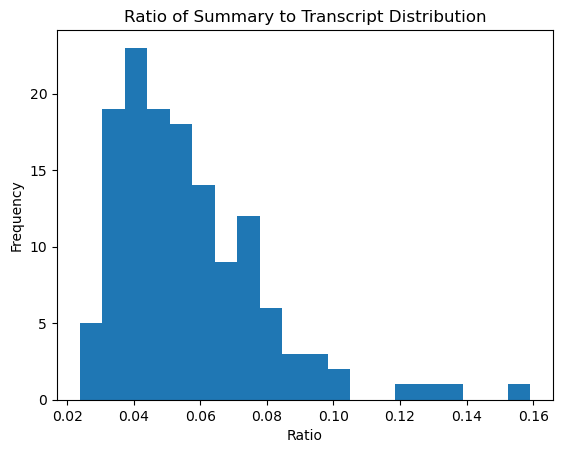

In [35]:
plt.hist(df["ratio_summary_to_transcript"], bins=20)
plt.title("Ratio of Summary to Transcript Distribution")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()

In [32]:
print("\nTop 5 longest meetings:")
print(df.nlargest(5, "transcript_length")[["meeting_id", "transcript_length", "summary_length", "ratio_summary_to_transcript"]])


Top 5 longest meetings:
    meeting_id  transcript_length  summary_length  ratio_summary_to_transcript
77     TS3005d              11218             293                     0.026119
81     TS3008d              10267             341                     0.033213
116    TS3006d              10217             303                     0.029656
95     TS3012b               9949             590                     0.059302
136    TS3007d               9713             265                     0.027283
